In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
from models.cbam_nnunet import nnUNet3D_CBAM
from utils.unets_helper_functions import (show_organ_overlay,
                    show_difference_map,
                    sliding_window_cbam)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = nnUNet3D_CBAM(
    in_channels=1,
    out_channels=7,
    base_filters=24
).to(device)
model_path = "../experiments/sdm_cbam/best_dice_model.pth"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model loaded for testing.")


C:\Users\dhanu\AppData\Local\Temp\ipykernel_27144\3650938334.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Model loaded for testing.


In [4]:
FOLD = 0

with open(f"../data/splits/fold_{FOLD}/train.txt") as f:
    train_cases = f.read().splitlines()

with open(f"../data/splits/fold_{FOLD}/val.txt") as f:
    val_cases = f.read().splitlines()

In [5]:
case = val_cases[8]  
print("Testing case:", case)

image = nib.load(f"../data/processed/imagesTr/{case}.nii.gz").get_fdata()
label = nib.load(f"../data/processed/labelsTr/{case}.nii.gz").get_fdata()


Testing case: case_02


In [6]:
pred = sliding_window_cbam(
    model,
    image,
    patch_size=96,
    stride=48,
    device=device
)

print("Prediction shape:", pred.shape)


Volume: 272x466x466 | Patches: 405 | Stride: 48
Prediction shape: (272, 466, 466)


In [7]:
z = image.shape[0] // 2

ct_slice = image[z]
gt_slice = label[z]
pred_slice = pred[z]

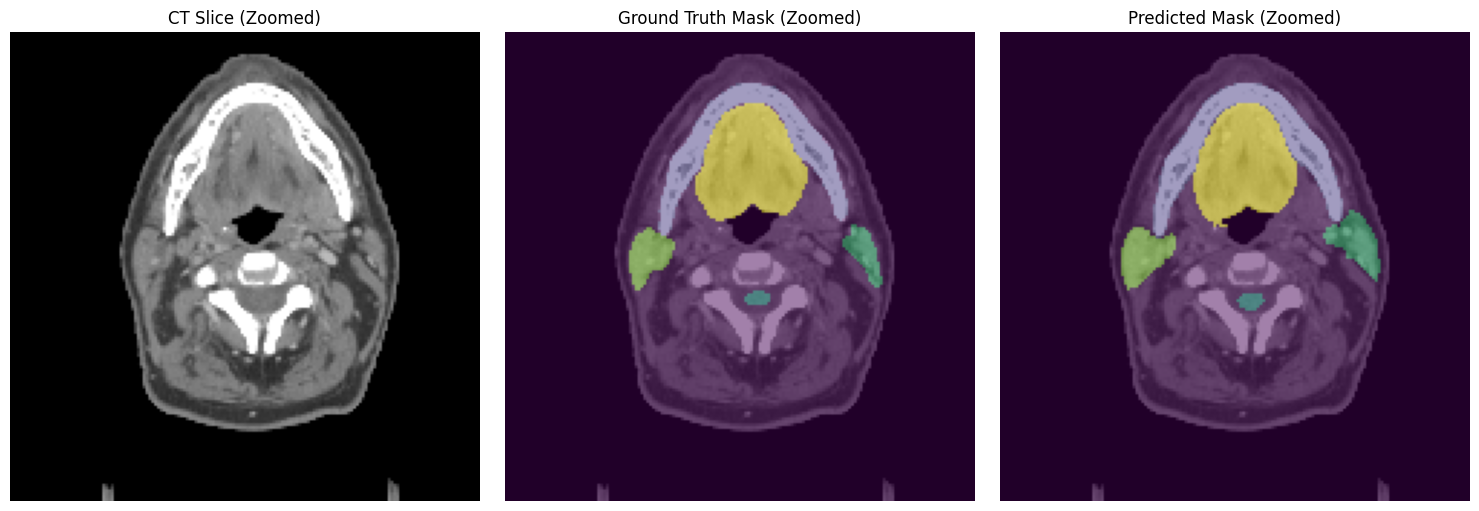

In [8]:
def zoom_center(img, zoom_factor=0.5):
    h, w = img.shape[:2]
    
    # New cropped size
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    
    # Center crop coordinates
    start_h = (h - new_h) // 2
    start_w = (w - new_w) // 2
    
    return img[start_h:start_h+new_h, start_w:start_w+new_w]

# Apply zoom
ct_zoom = zoom_center(ct_slice, 0.35)
gt_zoom = zoom_center(gt_slice, 0.35)
pred_zoom = zoom_center(pred_slice, 0.35)

plt.figure(figsize=(15,5))

# CT
plt.subplot(1,3,1)
plt.imshow(ct_zoom, cmap='gray')
plt.title("CT Slice (Zoomed)")
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.imshow(ct_zoom, cmap='gray')
plt.imshow(gt_zoom, alpha=0.5)
plt.title("Ground Truth Mask (Zoomed)")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(ct_zoom, cmap='gray')
plt.imshow(pred_zoom, alpha=0.5)
plt.title("Predicted Mask (Zoomed)")
plt.axis("off")

plt.tight_layout()
plt.show()

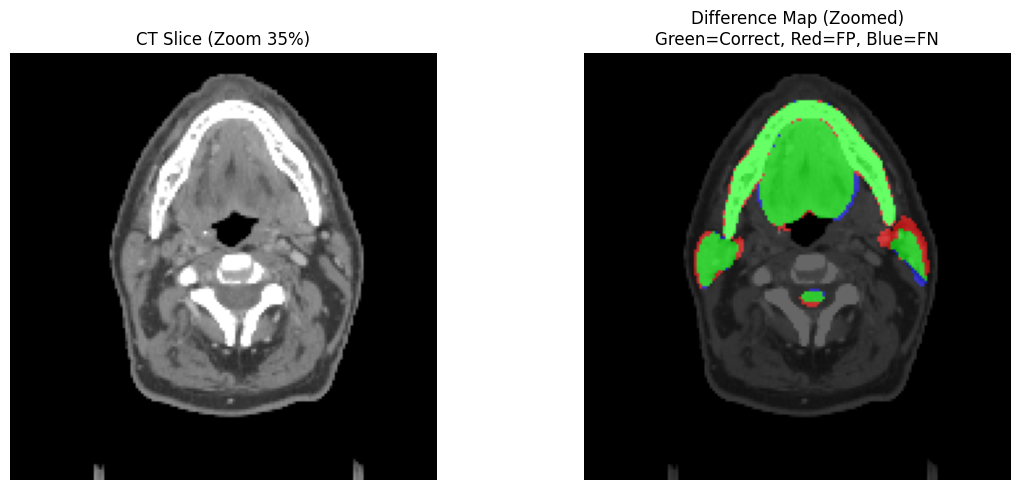

In [9]:
show_difference_map(ct_slice, gt_slice, pred_slice,zoom_factor=0.35)

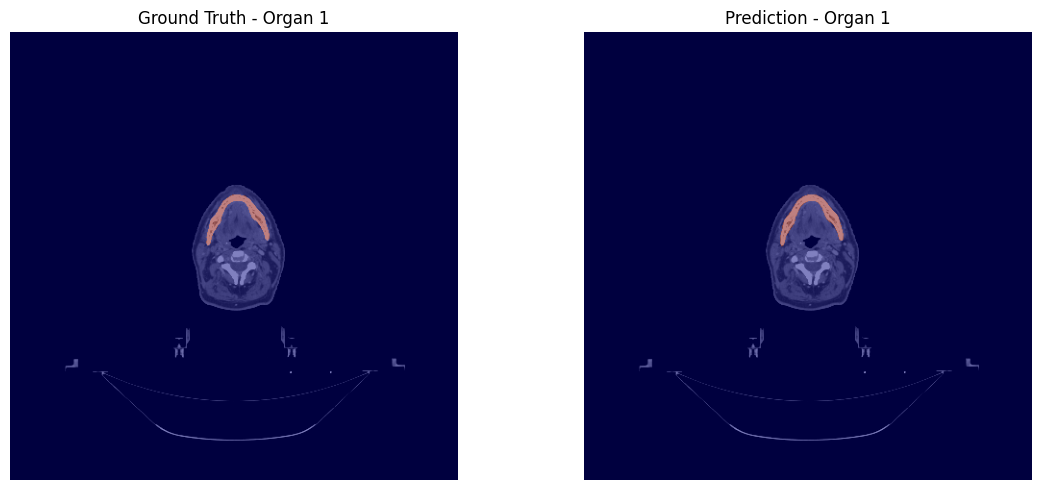

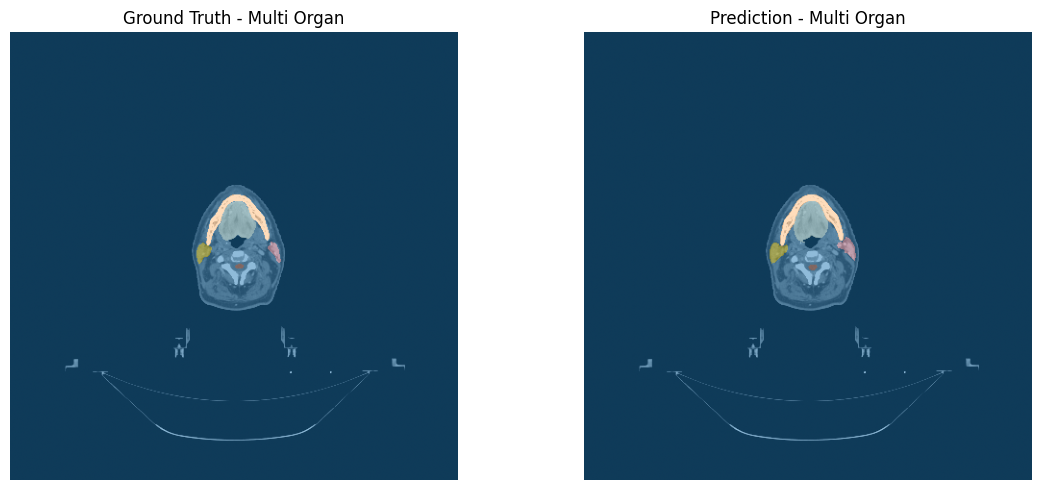

In [10]:
show_organ_overlay(ct_slice, gt_slice, pred_slice,organ_id=1)
show_organ_overlay(ct_slice, gt_slice, pred_slice)

In [11]:
import ipywidgets as widgets
from IPython.display import display

def interactive_slice_viewer(volume, title="Volume"):

    def view_slice(z):
        plt.figure(figsize=(6,6))
        plt.imshow(volume[z], cmap='gray')
        plt.title(f"{title} - Slice {z}")
        plt.axis("off")
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=volume.shape[0]-1,
        step=1,
        value=volume.shape[0]//2
    )

    widgets.interact(view_slice, z=slider)


interactive_slice_viewer(image, title="CT")
interactive_slice_viewer(pred, title="Prediction")
interactive_slice_viewer(label, title="Ground Truth")

interactive(children=(IntSlider(value=136, description='z', max=271), Output()), _dom_classes=('widget-interac…

interactive(children=(IntSlider(value=136, description='z', max=271), Output()), _dom_classes=('widget-interac…

interactive(children=(IntSlider(value=136, description='z', max=271), Output()), _dom_classes=('widget-interac…